# Discriminator Training Notebook

Train a discriminator to classify real vs fake motion clips and visualize training progress.

In [59]:
import os
import time
from typing import Dict, List, Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

# Set environment variables before importing track_mjx
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from track_mjx.analysis.discriminator import (
    MotionClipDataset,
    create_train_test_split,
    load_h5_dataset,
    load_h5_metadata,
    make_discriminator_network,
)
from track_mjx.analysis.discriminator.data_loading import create_batches
from track_mjx.analysis.discriminator.discriminator_train import (
    DiscriminatorParams,
    TrainingState,
    binary_cross_entropy_loss,
    compute_accuracy,
    create_eval_step,
    create_train_step,
    evaluate,
)

## Configuration

Set the path to your H5 dataset and configure training parameters.

In [60]:
# Data configuration
H5_PATH = "/home/mila/a/aidan.sirbu/track-mjx/data/discriminator_dataset_260110_202231_055567_23.h5"

# Available datasets from collect_rollout_dataset.py:
#   - original_qpos: Original reference motion capture data
#   - encoder_decoder_qpos: Rollouts from encoder-decoder pipeline
#   - prior_logvar_-4_qpos: Prior rollouts with logvar=-4 (std~0.14)
#   - prior_logvar_-2_qpos: Prior rollouts with logvar=-2 (std~0.37)
#   - prior_logvar_0_qpos: Prior rollouts with logvar=0 (std=1.0)
#   - prior_deterministic_qpos: Prior rollouts using mean (no sampling)
#   - prior_predicted_logvar_qpos: Prior rollouts using network-predicted logvar
REAL_DATASET = "encoder_decoder_qpos"  # Dataset name for "real" samples
FAKE_DATASET = "prior_predicted_logvar_qpos"  # Dataset name for "fake" samples
TRAIN_RATIO = 0.8
SPLIT_SEED = 42

# Clip length configuration
# Set to None to use full clips, or a value <= num_steps to truncate clips
CLIP_LENGTH = 200  # e.g., 200 to truncate to first 200 time steps

# Window configuration
# Set to None to use full clips, or a divisor of CLIP_LENGTH (or num_steps if CLIP_LENGTH is None)
WINDOW_SIZE = None  # Number of time steps per window (must divide clip length evenly)

# Network configuration
HIDDEN_LAYER_SIZES = (256, 256, 256)
DROPOUT_RATE = 0.1
USE_LAYER_NORM = True

# Training configuration
NUM_EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0
SEED = 0

# Data filtering options
EXCLUDE_ROOT = False  # Exclude first 7 qpos dims (root position + quaternion)
EXCLUDE_ZERO_JOINTS = False  # Exclude joints that are always zero

## Load Data

In [61]:
# Check if using single dataset mode (baseline)
single_dataset_mode = REAL_DATASET == FAKE_DATASET
if single_dataset_mode:
    print(f"Single dataset mode: both real and fake use '{REAL_DATASET}'.")
    print("This is a baseline where the network should NOT learn (expected ~50% accuracy).")

# Load datasets
print(f"Loading data from: {H5_PATH}")
print(f"Real dataset: {REAL_DATASET}")
print(f"Fake dataset: {FAKE_DATASET}")

real_data = load_h5_dataset(H5_PATH, REAL_DATASET)
fake_data = load_h5_dataset(H5_PATH, FAKE_DATASET)
metadata = load_h5_metadata(H5_PATH)

original_num_steps = real_data.shape[1]
print(f"\nReal data shape: {real_data.shape}")
print(f"Fake data shape: {fake_data.shape}")
print(f"H5 metadata: {metadata}")

# Truncate clips if CLIP_LENGTH is specified
if CLIP_LENGTH is not None:
    if CLIP_LENGTH > original_num_steps:
        raise ValueError(
            f"CLIP_LENGTH ({CLIP_LENGTH}) cannot exceed original num_steps ({original_num_steps})"
        )
    real_data = real_data[:, :CLIP_LENGTH, :]
    fake_data = fake_data[:, :CLIP_LENGTH, :]
    print(f"\nTruncated clips to {CLIP_LENGTH} time steps (discarded last {original_num_steps - CLIP_LENGTH})")
    print(f"  Real data shape: {real_data.shape}")
    print(f"  Fake data shape: {fake_data.shape}")

# Effective number of time steps after truncation
num_steps = real_data.shape[1]

# Validate window size
if WINDOW_SIZE is not None:
    if num_steps % WINDOW_SIZE != 0:
        valid_divisors = [i for i in range(1, num_steps + 1) if num_steps % i == 0]
        raise ValueError(
            f"WINDOW_SIZE ({WINDOW_SIZE}) must evenly divide num_steps ({num_steps}). "
            f"Valid window sizes: {valid_divisors}"
        )
    num_windows = num_steps // WINDOW_SIZE
    print(f"\nWindow size: {WINDOW_SIZE} time steps")
    print(f"Each clip will be split into {num_windows} windows")
else:
    print(f"\nUsing full clips ({num_steps} time steps)")

Loading data from: /home/mila/a/aidan.sirbu/track-mjx/data/discriminator_dataset_260110_202231_055567_23.h5
Real dataset: encoder_decoder_qpos
Fake dataset: prior_predicted_logvar_qpos

Real data shape: (842, 250, 74)
Fake data shape: (842, 250, 74)
H5 metadata: {'checkpoint_path': '/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260110_202231_055567', 'logvars': array([-4., -2.,  0.]), 'num_clips': np.int64(842), 'num_steps': np.int64(250), 'qpos_dim': np.int64(74)}

Truncated clips to 200 time steps (discarded last 50)
  Real data shape: (842, 200, 74)
  Fake data shape: (842, 200, 74)

Using full clips (200 time steps)


In [62]:
# Create train/test splits
dataset = create_train_test_split(
    real_data=real_data,
    fake_data=fake_data,
    train_ratio=TRAIN_RATIO,
    seed=SPLIT_SEED,
    single_dataset_mode=single_dataset_mode,
)

print(f"Train samples: {len(dataset.train_real)} real, {len(dataset.train_fake)} fake")
print(f"Test samples: {len(dataset.test_real)} real, {len(dataset.test_fake)} fake")

Train samples: 673 real, 673 fake
Test samples: 169 real, 169 fake


## Prepare Data (Apply Filtering)

In [63]:
# Indices of joints that are always zero in the data
ZERO_JOINT_INDICES = [
    18, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
    40, 41, 42, 43, 44, 45, 46, 47, 48, 57, 65, 73
]

# Determine which qpos indices to keep
all_indices = set(range(74))  # Original qpos has 74 dimensions
indices_to_exclude = set()

if EXCLUDE_ROOT:
    # Exclude first 7 dims: root position (3) + root quaternion (4)
    indices_to_exclude.update(range(7))
    print("Excluding root (indices 0-6): root position + quaternion")

if EXCLUDE_ZERO_JOINTS:
    indices_to_exclude.update(ZERO_JOINT_INDICES)
    print(f"Excluding zero joints ({len(ZERO_JOINT_INDICES)} indices)")

# Compute indices to keep
indices_to_keep = sorted(all_indices - indices_to_exclude)

if len(indices_to_keep) < 74:
    print(f"Keeping {len(indices_to_keep)} of 74 qpos dimensions (excluding {74 - len(indices_to_keep)})")
    # Slice data to keep only selected indices
    dataset = MotionClipDataset(
        train_real=dataset.train_real[:, :, indices_to_keep],
        train_fake=dataset.train_fake[:, :, indices_to_keep],
        test_real=dataset.test_real[:, :, indices_to_keep],
        test_fake=dataset.test_fake[:, :, indices_to_keep],
        metadata=dataset.metadata,
    )


def split_clips_into_windows(data: np.ndarray, window_size: int) -> np.ndarray:
    """Split clips into smaller windows along the time dimension.
    
    Args:
        data: Array of shape (num_clips, num_steps, qpos_dim).
        window_size: Number of time steps per window. Must evenly divide num_steps.
        
    Returns:
        Array of shape (num_clips * num_windows, window_size, qpos_dim).
    """
    num_clips, num_steps, qpos_dim = data.shape
    num_windows = num_steps // window_size
    # Reshape to (num_clips, num_windows, window_size, qpos_dim)
    reshaped = data.reshape(num_clips, num_windows, window_size, qpos_dim)
    # Flatten first two dimensions: (num_clips * num_windows, window_size, qpos_dim)
    return reshaped.reshape(-1, window_size, qpos_dim)


# Apply windowing if configured (AFTER train/test split to avoid data leakage)
if WINDOW_SIZE is not None:
    original_train_real = len(dataset.train_real)
    original_train_fake = len(dataset.train_fake)
    original_test_real = len(dataset.test_real)
    original_test_fake = len(dataset.test_fake)
    
    dataset = MotionClipDataset(
        train_real=split_clips_into_windows(dataset.train_real, WINDOW_SIZE),
        train_fake=split_clips_into_windows(dataset.train_fake, WINDOW_SIZE),
        test_real=split_clips_into_windows(dataset.test_real, WINDOW_SIZE),
        test_fake=split_clips_into_windows(dataset.test_fake, WINDOW_SIZE),
        metadata=dataset.metadata,
    )
    
    print(f"\nAfter windowing (window_size={WINDOW_SIZE}):")
    print(f"  Train real: {original_train_real} clips -> {len(dataset.train_real)} windows")
    print(f"  Train fake: {original_train_fake} clips -> {len(dataset.train_fake)} windows")
    print(f"  Test real: {original_test_real} clips -> {len(dataset.test_real)} windows")
    print(f"  Test fake: {original_test_fake} clips -> {len(dataset.test_fake)} windows")

# Determine input size from data shape
sample_shape = dataset.train_real.shape[1:]  # (num_steps or window_size, qpos_dim)
input_size = int(np.prod(sample_shape))

print(f"\nInput size: {input_size} (from shape {sample_shape})")


Input size: 14800 (from shape (200, 74))


## Initialize Network and Optimizer

In [64]:
# Create network
_, init_fn, apply_fn = make_discriminator_network(
    input_size=input_size,
    hidden_layer_sizes=HIDDEN_LAYER_SIZES,
    dropout_rate=DROPOUT_RATE,
    use_layer_norm=USE_LAYER_NORM,
)

# Initialize parameters
key = jax.random.PRNGKey(SEED)
init_params = init_fn(key)

# Create optimizer with gradient clipping
optimizer = optax.chain(
    optax.clip_by_global_norm(GRAD_CLIP_NORM),
    optax.adamw(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
)

# Initialize training state
training_state = TrainingState(
    optimizer_state=optimizer.init(init_params),
    params=DiscriminatorParams(params=init_params),
    epoch=0,
    step=0,
    best_test_accuracy=0.0,
)

# Create JIT-compiled step functions
train_step_fn = create_train_step(apply_fn, optimizer)
eval_step_fn = create_eval_step(apply_fn)

print(f"Network architecture: {list(HIDDEN_LAYER_SIZES)}")
print(f"Dropout rate: {DROPOUT_RATE}")
print(f"Layer norm: {USE_LAYER_NORM}")

Network architecture: [256, 256, 256]
Dropout rate: 0.1
Layer norm: True


## Training Loop

In [7]:
# Storage for metrics
history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

# Evaluate before training
initial_test_metrics = evaluate(
    training_state.params.params,
    eval_step_fn,
    dataset.test_real,
    dataset.test_fake,
    BATCH_SIZE,
)

training_state = training_state.replace(
    best_test_accuracy=initial_test_metrics["accuracy"]
)

history["epoch"].append(0)
history["train_loss"].append(None)
history["train_accuracy"].append(None)
history["test_loss"].append(initial_test_metrics["loss"])
history["test_accuracy"].append(initial_test_metrics["accuracy"])

print(f"Epoch 0 (before training) - Test Loss: {initial_test_metrics['loss']:.4f}, Test Acc: {initial_test_metrics['accuracy']:.4f}")

Epoch 0 (before training) - Test Loss: 0.7362, Test Acc: 0.4875


In [8]:
# Training loop
rng = np.random.default_rng(SEED)

print(f"Training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    epoch_losses = []
    epoch_accuracies = []

    # Generate random keys for this epoch's dropout
    key, epoch_key = jax.random.split(key)
    max_batches = min(len(dataset.train_real), len(dataset.train_fake)) // (BATCH_SIZE // 2)
    batch_keys = jax.random.split(epoch_key, max_batches + 1)
    batch_idx = 0

    # Training batches
    for batch_data, batch_labels in create_batches(
        dataset.train_real, dataset.train_fake, BATCH_SIZE, rng, shuffle=True
    ):
        batch_data_jax = jnp.array(batch_data)
        batch_labels_jax = jnp.array(batch_labels)

        training_state, metrics = train_step_fn(
            training_state, batch_data_jax, batch_labels_jax, batch_keys[batch_idx]
        )

        epoch_losses.append(float(metrics["loss"]))
        epoch_accuracies.append(float(metrics["accuracy"]))
        batch_idx += 1

    # Update epoch count
    training_state = training_state.replace(epoch=epoch + 1)

    # Compute epoch averages
    train_loss = np.mean(epoch_losses)
    train_accuracy = np.mean(epoch_accuracies)

    # Evaluate on test set
    test_metrics = evaluate(
        training_state.params.params,
        eval_step_fn,
        dataset.test_real,
        dataset.test_fake,
        BATCH_SIZE,
    )

    # Update best accuracy
    if test_metrics["accuracy"] > training_state.best_test_accuracy:
        training_state = training_state.replace(
            best_test_accuracy=test_metrics["accuracy"]
        )

    epoch_time = time.time() - epoch_start

    # Store metrics
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_metrics["loss"])
    history["test_accuracy"].append(test_metrics["accuracy"])

    # Print progress every 5 epochs or on last epoch
    if (epoch + 1) % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(
            f"Epoch {epoch + 1:3d}/{NUM_EPOCHS} - "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
            f"Test Loss: {test_metrics['loss']:.4f}, Test Acc: {test_metrics['accuracy']:.4f}, "
            f"Time: {epoch_time:.1f}s"
        )

print(f"\nTraining complete!")
print(f"Best test accuracy: {training_state.best_test_accuracy:.4f}")

Training for 100 epochs...

Epoch   5/100 - Train Loss: 0.5059, Train Acc: 0.7448, Test Loss: 0.6013, Test Acc: 0.6906, Time: 0.1s
Epoch  10/100 - Train Loss: 0.3780, Train Acc: 0.8304, Test Loss: 0.6326, Test Acc: 0.7000, Time: 0.1s
Epoch  15/100 - Train Loss: 0.2551, Train Acc: 0.8914, Test Loss: 0.7054, Test Acc: 0.7000, Time: 0.1s
Epoch  20/100 - Train Loss: 0.1843, Train Acc: 0.9204, Test Loss: 0.7013, Test Acc: 0.7625, Time: 0.1s
Epoch  25/100 - Train Loss: 0.1206, Train Acc: 0.9591, Test Loss: 0.8097, Test Acc: 0.7594, Time: 0.1s
Epoch  30/100 - Train Loss: 0.0796, Train Acc: 0.9740, Test Loss: 0.9106, Test Acc: 0.7281, Time: 0.1s
Epoch  35/100 - Train Loss: 0.0510, Train Acc: 0.9844, Test Loss: 0.9161, Test Acc: 0.7750, Time: 0.1s
Epoch  40/100 - Train Loss: 0.0424, Train Acc: 0.9859, Test Loss: 1.0534, Test Acc: 0.7344, Time: 0.1s
Epoch  45/100 - Train Loss: 0.0508, Train Acc: 0.9799, Test Loss: 0.9932, Test Acc: 0.7844, Time: 0.1s
Epoch  50/100 - Train Loss: 0.0312, Train Acc

## Visualize Training Progress

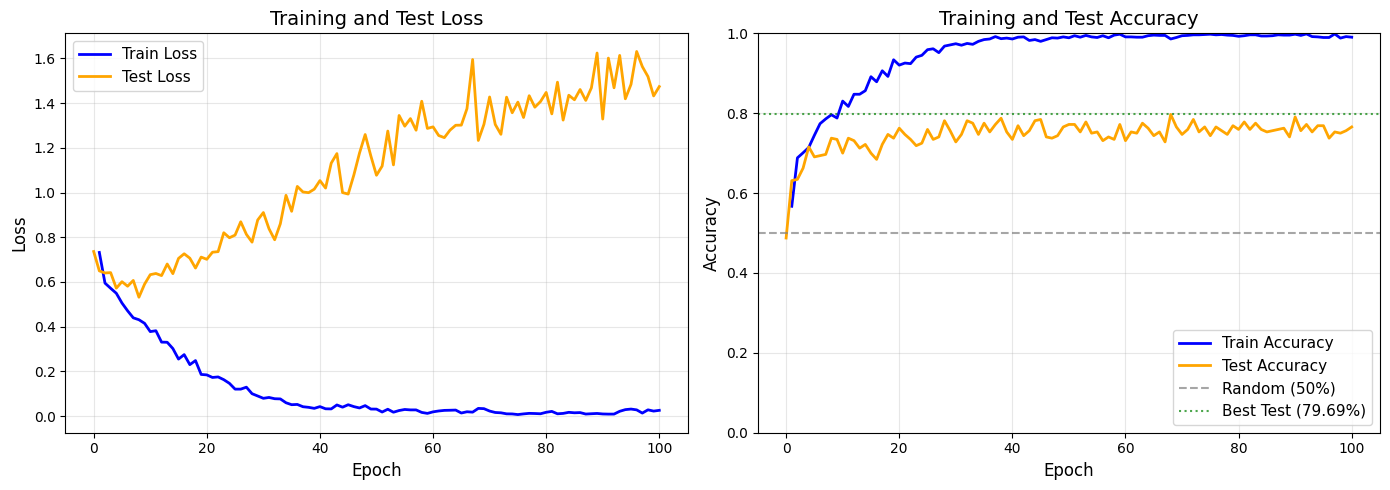

In [9]:
# Convert to arrays for plotting (skip epoch 0 for train metrics since they're None)
epochs = np.array(history["epoch"])
train_epochs = epochs[1:]  # Skip epoch 0
train_loss = np.array([x for x in history["train_loss"] if x is not None])
train_accuracy = np.array([x for x in history["train_accuracy"] if x is not None])
test_loss = np.array(history["test_loss"])
test_accuracy = np.array(history["test_accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1 = axes[0]
ax1.plot(train_epochs, train_loss, label="Train Loss", color="blue", linewidth=2)
ax1.plot(epochs, test_loss, label="Test Loss", color="orange", linewidth=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Training and Test Loss", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2 = axes[1]
ax2.plot(train_epochs, train_accuracy, label="Train Accuracy", color="blue", linewidth=2)
ax2.plot(epochs, test_accuracy, label="Test Accuracy", color="orange", linewidth=2)
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Random (50%)")
ax2.axhline(y=training_state.best_test_accuracy, color="green", linestyle=":", alpha=0.7, 
            label=f"Best Test ({training_state.best_test_accuracy:.2%})")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_title("Training and Test Accuracy", fontsize=14)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=11, loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [10]:
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Dataset: {REAL_DATASET} vs {FAKE_DATASET}")
print(f"Single dataset mode: {single_dataset_mode}")
print(f"")
print(f"Final train accuracy: {train_accuracy[-1]:.4f}")
print(f"Final test accuracy:  {test_accuracy[-1]:.4f}")
print(f"Best test accuracy:   {training_state.best_test_accuracy:.4f}")
print(f"")
print(f"Final train loss: {train_loss[-1]:.4f}")
print(f"Final test loss:  {test_loss[-1]:.4f}")
print("=" * 60)

if single_dataset_mode:
    print("\nNote: Single dataset mode was used (baseline).")
    print("Expected accuracy is ~50% (random chance).")

TRAINING SUMMARY
Dataset: encoder_decoder_qpos vs prior_predicted_logvar_qpos
Single dataset mode: False

Final train accuracy: 0.9903
Final test accuracy:  0.7656
Best test accuracy:   0.7969

Final train loss: 0.0258
Final test loss:  1.4740


## Multi-Dataset Comparison

Train discriminators for each fake dataset against the same real dataset and compare their test accuracies over training.

In [45]:
# All available datasets
ALL_DATASETS = [
    "original_qpos",
    "encoder_decoder_qpos",
    "prior_logvar_-4_qpos",
    "prior_logvar_-2_qpos",
    "prior_logvar_0_qpos",
    "prior_deterministic_qpos",
    "prior_predicted_logvar_qpos",
]

# Configuration for multi-dataset comparison
COMPARISON_REAL_DATASET = "encoder_decoder_qpos"
COMPARISON_NUM_EPOCHS = NUM_EPOCHS  # Use same number of epochs

# Get fake datasets (all datasets except the real one)
fake_datasets = [ds for ds in ALL_DATASETS]

print(f"Real dataset: {COMPARISON_REAL_DATASET}")
print(f"Fake datasets to compare: {fake_datasets}")

Real dataset: encoder_decoder_qpos
Fake datasets to compare: ['original_qpos', 'encoder_decoder_qpos', 'prior_logvar_-4_qpos', 'prior_logvar_-2_qpos', 'prior_logvar_0_qpos', 'prior_deterministic_qpos', 'prior_predicted_logvar_qpos']


In [46]:
def split_clips_into_windows_fn(data: np.ndarray, window_size: int) -> np.ndarray:
    """Split clips into smaller windows along the time dimension.
    
    Args:
        data: Array of shape (num_clips, num_steps, qpos_dim).
        window_size: Number of time steps per window. Must evenly divide num_steps.
        
    Returns:
        Array of shape (num_clips * num_windows, window_size, qpos_dim).
    """
    num_clips, num_steps, qpos_dim = data.shape
    num_windows = num_steps // window_size
    reshaped = data.reshape(num_clips, num_windows, window_size, qpos_dim)
    return reshaped.reshape(-1, window_size, qpos_dim)


def train_discriminator_for_dataset(
    real_dataset_name: str,
    fake_dataset_name: str,
    h5_path: str,
    num_epochs: int,
    batch_size: int,
    hidden_layer_sizes: tuple,
    learning_rate: float,
    weight_decay: float,
    grad_clip_norm: float,
    dropout_rate: float,
    use_layer_norm: bool,
    train_ratio: float,
    split_seed: int,
    seed: int,
    exclude_root: bool = False,
    exclude_zero_joints: bool = False,
    window_size: int = None,
    clip_length: int = None,
) -> Dict[str, List]:
    """Train a discriminator and return the training history."""
    
    # Load data
    real_data = load_h5_dataset(h5_path, real_dataset_name)
    fake_data = load_h5_dataset(h5_path, fake_dataset_name)
    
    # Truncate clips if clip_length is specified
    if clip_length is not None:
        if clip_length > real_data.shape[1]:
            raise ValueError(
                f"clip_length ({clip_length}) cannot exceed num_steps ({real_data.shape[1]})"
            )
        real_data = real_data[:, :clip_length, :]
        fake_data = fake_data[:, :clip_length, :]
    
    # Validate window size if provided
    if window_size is not None:
        num_steps = real_data.shape[1]
        if num_steps % window_size != 0:
            raise ValueError(
                f"window_size ({window_size}) must evenly divide num_steps ({num_steps})"
            )
    
    single_dataset_mode = real_dataset_name == fake_dataset_name
    
    # Create train/test splits
    ds = create_train_test_split(
        real_data=real_data,
        fake_data=fake_data,
        train_ratio=train_ratio,
        seed=split_seed,
        single_dataset_mode=single_dataset_mode,
    )
    
    # Apply filtering if needed
    if exclude_root or exclude_zero_joints:
        ZERO_JOINT_INDICES = [
            18, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
            40, 41, 42, 43, 44, 45, 46, 47, 48, 57, 65, 73
        ]
        all_indices = set(range(74))
        indices_to_exclude = set()
        if exclude_root:
            indices_to_exclude.update(range(7))
        if exclude_zero_joints:
            indices_to_exclude.update(ZERO_JOINT_INDICES)
        indices_to_keep = sorted(all_indices - indices_to_exclude)
        
        ds = MotionClipDataset(
            train_real=ds.train_real[:, :, indices_to_keep],
            train_fake=ds.train_fake[:, :, indices_to_keep],
            test_real=ds.test_real[:, :, indices_to_keep],
            test_fake=ds.test_fake[:, :, indices_to_keep],
            metadata=ds.metadata,
        )
    
    # Apply windowing if configured (AFTER split to avoid data leakage)
    if window_size is not None:
        ds = MotionClipDataset(
            train_real=split_clips_into_windows_fn(ds.train_real, window_size),
            train_fake=split_clips_into_windows_fn(ds.train_fake, window_size),
            test_real=split_clips_into_windows_fn(ds.test_real, window_size),
            test_fake=split_clips_into_windows_fn(ds.test_fake, window_size),
            metadata=ds.metadata,
        )
    
    # Determine input size
    sample_shape = ds.train_real.shape[1:]
    input_size = int(np.prod(sample_shape))
    
    # Create network
    _, init_fn, apply_fn = make_discriminator_network(
        input_size=input_size,
        hidden_layer_sizes=hidden_layer_sizes,
        dropout_rate=dropout_rate,
        use_layer_norm=use_layer_norm,
    )
    
    # Initialize
    key = jax.random.PRNGKey(seed)
    init_params = init_fn(key)
    
    optimizer = optax.chain(
        optax.clip_by_global_norm(grad_clip_norm),
        optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay),
    )
    
    state = TrainingState(
        optimizer_state=optimizer.init(init_params),
        params=DiscriminatorParams(params=init_params),
        epoch=0,
        step=0,
        best_test_accuracy=0.0,
    )
    
    train_step_fn = create_train_step(apply_fn, optimizer)
    eval_step_fn = create_eval_step(apply_fn)
    
    # History
    hist = {"epoch": [], "test_accuracy": [], "train_accuracy": []}
    
    # Initial eval
    initial_metrics = evaluate(state.params.params, eval_step_fn, ds.test_real, ds.test_fake, batch_size)
    hist["epoch"].append(0)
    hist["test_accuracy"].append(initial_metrics["accuracy"])
    hist["train_accuracy"].append(None)
    
    # Training loop
    rng = np.random.default_rng(seed)
    
    for epoch in range(num_epochs):
        epoch_accuracies = []
        key, epoch_key = jax.random.split(key)
        max_batches = min(len(ds.train_real), len(ds.train_fake)) // (batch_size // 2)
        batch_keys = jax.random.split(epoch_key, max_batches + 1)
        batch_idx = 0
        
        for batch_data, batch_labels in create_batches(
            ds.train_real, ds.train_fake, batch_size, rng, shuffle=True
        ):
            batch_data_jax = jnp.array(batch_data)
            batch_labels_jax = jnp.array(batch_labels)
            state, metrics = train_step_fn(state, batch_data_jax, batch_labels_jax, batch_keys[batch_idx])
            epoch_accuracies.append(float(metrics["accuracy"]))
            batch_idx += 1
        
        state = state.replace(epoch=epoch + 1)
        train_acc = np.mean(epoch_accuracies)
        
        test_metrics = evaluate(state.params.params, eval_step_fn, ds.test_real, ds.test_fake, batch_size)
        
        hist["epoch"].append(epoch + 1)
        hist["test_accuracy"].append(test_metrics["accuracy"])
        hist["train_accuracy"].append(train_acc)
    
    return hist

In [ ]:
# Train discriminators for each fake dataset
all_histories = {}

for i, fake_ds in enumerate(fake_datasets):
    print(f"\n[{i+1}/{len(fake_datasets)}] Training: {COMPARISON_REAL_DATASET} vs {fake_ds}")
    
    hist = train_discriminator_for_dataset(
        real_dataset_name=COMPARISON_REAL_DATASET,
        fake_dataset_name=fake_ds,
        h5_path=H5_PATH,
        num_epochs=COMPARISON_NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        hidden_layer_sizes=HIDDEN_LAYER_SIZES,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        grad_clip_norm=GRAD_CLIP_NORM,
        dropout_rate=DROPOUT_RATE,
        use_layer_norm=USE_LAYER_NORM,
        train_ratio=TRAIN_RATIO,
        split_seed=SPLIT_SEED,
        seed=SEED,
        exclude_root=EXCLUDE_ROOT,
        exclude_zero_joints=EXCLUDE_ZERO_JOINTS,
        window_size=WINDOW_SIZE,
        clip_length=CLIP_LENGTH,
    )
    
    all_histories[fake_ds] = hist
    final_acc = hist["test_accuracy"][-1]
    best_acc = max(hist["test_accuracy"])
    print(f"    Final test accuracy: {final_acc:.4f}, Best: {best_acc:.4f}")

print("\nAll training complete!")

In [28]:
# Summary table of results
print("=" * 90)
print(f"MULTI-DATASET COMPARISON SUMMARY")
print(f"Real dataset: {COMPARISON_REAL_DATASET}")
print("=" * 90)
print(f"{'Fake Dataset':<35} {'Final Acc':>12} {'Best Acc':>12} {'Last 50 Mean':>14} {'Std':>10}")
print("-" * 90)

# Sort by best accuracy descending
sorted_results = sorted(
    all_histories.items(),
    key=lambda x: max(x[1]["test_accuracy"]),
    reverse=True
)

for fake_ds, hist in sorted_results:
    test_accs = np.array(hist["test_accuracy"])
    final_acc = test_accs[-1]
    best_acc = np.max(test_accs)
    # Last 50 epochs (or all if fewer than 50)
    last_n = min(50, len(test_accs))
    last_50_mean = np.mean(test_accs[-last_n:])
    last_50_std = np.std(test_accs[-last_n:])
    print(f"{fake_ds:<35} {final_acc:>12.4f} {best_acc:>12.4f} {last_50_mean:>14.4f} {last_50_std:>10.4f}")

print("=" * 90)

MULTI-DATASET COMPARISON SUMMARY
Real dataset: encoder_decoder_qpos
Fake Dataset                           Final Acc     Best Acc   Last 50 Mean        Std
------------------------------------------------------------------------------------------
original_qpos                             1.0000       1.0000         1.0000     0.0000
prior_logvar_0_qpos                       0.7833       0.7977         0.7825     0.0034
prior_logvar_-2_qpos                      0.5800       0.6317         0.5844     0.0040
prior_predicted_logvar_qpos               0.5598       0.6077         0.5603     0.0039
prior_deterministic_qpos                  0.5431       0.5868         0.5383     0.0038
prior_logvar_-4_qpos                      0.5356       0.5774         0.5379     0.0036
encoder_decoder_qpos                      0.5247       0.5386         0.5202     0.0057


## prior_training_260110_202231_055567

### Checkpoint step 23
```==========================================================================================
MULTI-DATASET COMPARISON SUMMARY
Real dataset: encoder_decoder_qpos
==========================================================================================
Fake Dataset                           Final Acc     Best Acc   Last 50 Mean        Std
------------------------------------------------------------------------------------------
original_qpos                             1.0000       1.0000         1.0000     0.0000
prior_logvar_0_qpos                       0.8688       0.8969         0.8713     0.0047
prior_logvar_-2_qpos                      0.7469       0.7875         0.7491     0.0165
prior_deterministic_qpos                  0.7375       0.7719         0.7268     0.0167
prior_predicted_logvar_qpos               0.6969       0.7469         0.6914     0.0155
prior_logvar_-4_qpos                      0.6906       0.7344         0.6867     0.0123
encoder_decoder_qpos                      0.4766       0.5703         0.4858     0.0252
==========================================================================================

## prior_training_260109_172445_748931

### Checkpoint step 6
```==========================================================================================
MULTI-DATASET COMPARISON SUMMARY
Real dataset: encoder_decoder_qpos
==========================================================================================
Fake Dataset                           Final Acc     Best Acc   Last 50 Mean        Std
------------------------------------------------------------------------------------------
original_qpos                             1.0000       1.0000         1.0000     0.0000
prior_logvar_0_qpos                       0.8812       0.9250         0.8966     0.0111
prior_predicted_logvar_qpos               0.7969       0.8094         0.7837     0.0134
prior_logvar_-2_qpos                      0.7781       0.8063         0.7688     0.0135
prior_logvar_-4_qpos                      0.7500       0.7906         0.7621     0.0115
prior_deterministic_qpos                  0.7562       0.7875         0.7658     0.0117
encoder_decoder_qpos                      0.5000       0.5703         0.4791     0.0272
==========================================================================================

### Checkpoint step 15

```==========================================================================================
MULTI-DATASET COMPARISON SUMMARY
Real dataset: encoder_decoder_qpos
==========================================================================================
Fake Dataset                           Final Acc     Best Acc   Last 50 Mean        Std
------------------------------------------------------------------------------------------
original_qpos                             1.0000       1.0000         1.0000     0.0000
prior_logvar_0_qpos                       0.8938       0.9125         0.8936     0.0034
prior_logvar_-2_qpos                      0.7844       0.8063         0.7724     0.0170
prior_predicted_logvar_qpos               0.7562       0.7969         0.7537     0.0099
prior_deterministic_qpos                  0.7375       0.7719         0.7389     0.0170
prior_logvar_-4_qpos                      0.7281       0.7594         0.7261     0.0153
encoder_decoder_qpos                      0.4688       0.5469         0.4825     0.0245
==========================================================================================

### Checkpoint step 23
```==========================================================================================
MULTI-DATASET COMPARISON SUMMARY
Real dataset: encoder_decoder_qpos
==========================================================================================
Fake Dataset                           Final Acc     Best Acc   Last 50 Mean        Std
------------------------------------------------------------------------------------------
original_qpos                             1.0000       1.0000         1.0000     0.0000
prior_logvar_0_qpos                       0.8938       0.9062         0.8926     0.0026
prior_logvar_-2_qpos                      0.7250       0.7875         0.7467     0.0186
prior_deterministic_qpos                  0.7188       0.7719         0.7298     0.0140
prior_predicted_logvar_qpos               0.7000       0.7656         0.7159     0.0136
prior_logvar_-4_qpos                      0.7031       0.7344         0.6901     0.0132
encoder_decoder_qpos                      0.5000       0.5859         0.4820     0.0317
==========================================================================================

## Window Size Sweep

Train discriminators with varying window sizes to analyze how temporal context affects discrimination accuracy.

In [55]:
# Configuration for window size sweep
SWEEP_REAL_DATASET = "encoder_decoder_qpos"
SWEEP_FAKE_DATASET = "prior_predicted_logvar_qpos"  # Change this to compare different datasets
SWEEP_NUM_EPOCHS = NUM_EPOCHS  # Use same number of epochs as main training
SWEEP_BATCH_SIZE = 64  # Larger batch size for efficiency with more samples

# Clip length for sweep (truncate clips before windowing)
# Use a value with many divisors for more window size options
# 240 divisors (10-240): 10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240
SWEEP_CLIP_LENGTH = 240

# Window sizes to sweep (must all divide SWEEP_CLIP_LENGTH evenly)
# For clip_length=240: valid sizes are 10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240
WINDOW_SIZES = [10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240]

# Validate all window sizes
invalid_sizes = [ws for ws in WINDOW_SIZES if SWEEP_CLIP_LENGTH % ws != 0]
if invalid_sizes:
    valid_divisors = [i for i in range(10, SWEEP_CLIP_LENGTH + 1) if SWEEP_CLIP_LENGTH % i == 0]
    raise ValueError(
        f"Invalid window sizes for clip_length={SWEEP_CLIP_LENGTH}: {invalid_sizes}. "
        f"Valid sizes (>=10): {valid_divisors}"
    )

print(f"Real dataset: {SWEEP_REAL_DATASET}")
print(f"Fake dataset: {SWEEP_FAKE_DATASET}")
print(f"Clip length: {SWEEP_CLIP_LENGTH} (truncated from 250)")
print(f"Window sizes to sweep: {WINDOW_SIZES}")
print(f"Number of window sizes: {len(WINDOW_SIZES)}")

Real dataset: encoder_decoder_qpos
Fake dataset: prior_predicted_logvar_qpos
Clip length: 240 (truncated from 250)
Window sizes to sweep: [10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240]
Number of window sizes: 13


In [56]:
# Train discriminators for each window size
window_sweep_results = {}

print(f"Training {len(WINDOW_SIZES)} discriminators with varying window sizes...\n")

for i, ws in enumerate(WINDOW_SIZES):
    print(f"[{i+1}/{len(WINDOW_SIZES)}] Window size: {ws}")
    
    hist = train_discriminator_for_dataset(
        real_dataset_name=SWEEP_REAL_DATASET,
        fake_dataset_name=SWEEP_FAKE_DATASET,
        h5_path=H5_PATH,
        num_epochs=SWEEP_NUM_EPOCHS,
        batch_size=SWEEP_BATCH_SIZE,
        hidden_layer_sizes=HIDDEN_LAYER_SIZES,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        grad_clip_norm=GRAD_CLIP_NORM,
        dropout_rate=DROPOUT_RATE,
        use_layer_norm=USE_LAYER_NORM,
        train_ratio=TRAIN_RATIO,
        split_seed=SPLIT_SEED,
        seed=SEED,
        exclude_root=EXCLUDE_ROOT,
        exclude_zero_joints=EXCLUDE_ZERO_JOINTS,
        window_size=ws,
        clip_length=SWEEP_CLIP_LENGTH,
    )
    
    # Compute last 50 epochs statistics
    test_accs = np.array(hist["test_accuracy"])
    last_n = min(50, len(test_accs))
    last_50_mean = np.mean(test_accs[-last_n:])
    last_50_std = np.std(test_accs[-last_n:])
    
    window_sweep_results[ws] = {
        "history": hist,
        "last_50_mean": last_50_mean,
        "last_50_std": last_50_std,
    }
    
    print(f"    Last 50 mean: {last_50_mean:.4f} +/- {last_50_std:.4f}")

print("\nWindow size sweep complete!")

Training 13 discriminators with varying window sizes...

[1/13] Window size: 10
    Last 50 mean: 0.5330 +/- 0.0037
[2/13] Window size: 12
    Last 50 mean: 0.5420 +/- 0.0042
[3/13] Window size: 15
    Last 50 mean: 0.5470 +/- 0.0044
[4/13] Window size: 16
    Last 50 mean: 0.5549 +/- 0.0045
[5/13] Window size: 20
    Last 50 mean: 0.5594 +/- 0.0038
[6/13] Window size: 24
    Last 50 mean: 0.5593 +/- 0.0061
[7/13] Window size: 30
    Last 50 mean: 0.5691 +/- 0.0054
[8/13] Window size: 40
    Last 50 mean: 0.5825 +/- 0.0050
[9/13] Window size: 48
    Last 50 mean: 0.5941 +/- 0.0077
[10/13] Window size: 60
    Last 50 mean: 0.6192 +/- 0.0096
[11/13] Window size: 80
    Last 50 mean: 0.6382 +/- 0.0092
[12/13] Window size: 120
    Last 50 mean: 0.6635 +/- 0.0102
[13/13] Window size: 240
    Last 50 mean: 0.6862 +/- 0.0142

Window size sweep complete!


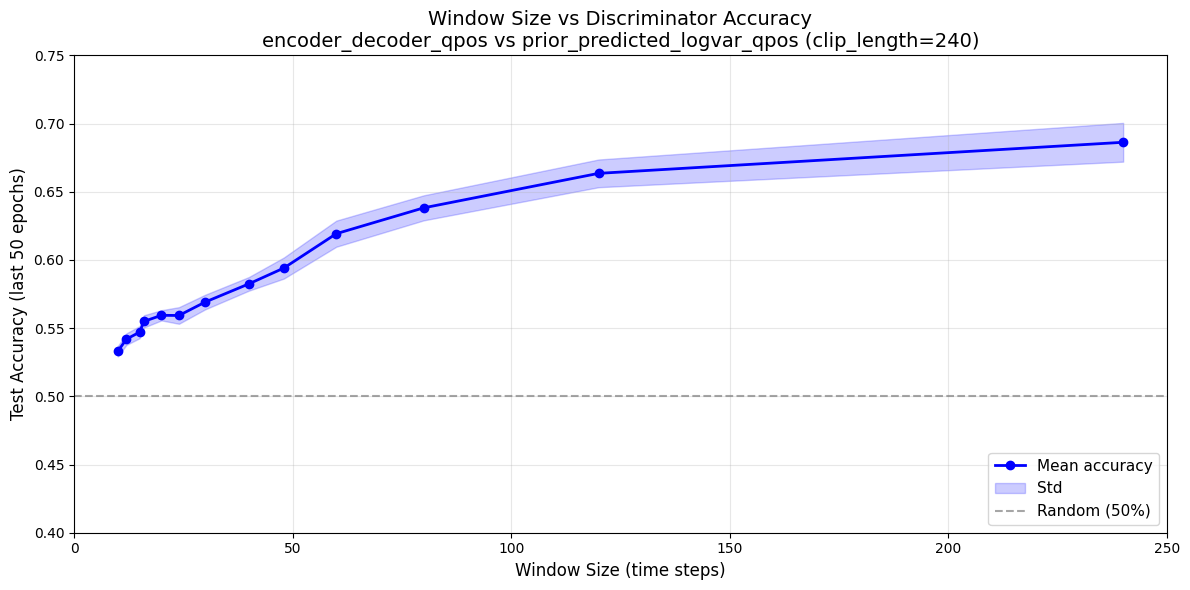


WINDOW SIZE SWEEP SUMMARY
Real: encoder_decoder_qpos vs Fake: prior_predicted_logvar_qpos
Clip length: 240
 Window Size     Mean Acc        Std
------------------------------------------------------------
          10       0.5330     0.0037
          12       0.5420     0.0042
          15       0.5470     0.0044
          16       0.5549     0.0045
          20       0.5594     0.0038
          24       0.5593     0.0061
          30       0.5691     0.0054
          40       0.5825     0.0050
          48       0.5941     0.0077
          60       0.6192     0.0096
          80       0.6382     0.0092
         120       0.6635     0.0102
         240       0.6862     0.0142


In [58]:
# Plot window size vs accuracy
window_sizes = np.array(sorted(window_sweep_results.keys()))
means = np.array([window_sweep_results[ws]["last_50_mean"] for ws in window_sizes])
stds = np.array([window_sweep_results[ws]["last_50_std"] for ws in window_sizes])

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean with shaded std region
ax.plot(window_sizes, means, color="blue", linewidth=2, marker="o", markersize=6, label="Mean accuracy")
ax.fill_between(window_sizes, means - stds, means + stds, color="blue", alpha=0.2, label="Std")

# Reference lines
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Random (50%)")

# Labels and formatting
ax.set_xlabel("Window Size (time steps)", fontsize=12)
ax.set_ylabel("Test Accuracy (last 50 epochs)", fontsize=12)
ax.set_title(
    f"Window Size vs Discriminator Accuracy\n"
    f"{SWEEP_REAL_DATASET} vs {SWEEP_FAKE_DATASET} (clip_length={SWEEP_CLIP_LENGTH})",
    fontsize=14
)
ax.set_xlim(0, max(window_sizes) + 10)
ax.set_ylim(0.4, 0.75)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 60)
print("WINDOW SIZE SWEEP SUMMARY")
print(f"Real: {SWEEP_REAL_DATASET} vs Fake: {SWEEP_FAKE_DATASET}")
print(f"Clip length: {SWEEP_CLIP_LENGTH}")
print("=" * 60)
print(f"{'Window Size':>12} {'Mean Acc':>12} {'Std':>10}")
print("-" * 60)
for ws in window_sizes:
    mean = window_sweep_results[ws]["last_50_mean"]
    std = window_sweep_results[ws]["last_50_std"]
    print(f"{ws:>12} {mean:>12.4f} {std:>10.4f}")
print("=" * 60)

## Multi-Dataset Window Size Sweep

Train discriminators with varying window sizes for multiple fake datasets and compare them on a single plot.

In [65]:
# Configuration for multi-dataset window size sweep
MULTI_SWEEP_REAL_DATASET = "encoder_decoder_qpos"
MULTI_SWEEP_FAKE_DATASETS = [
    "prior_logvar_-4_qpos",
    "prior_logvar_-2_qpos",
    "prior_logvar_0_qpos",
    "prior_deterministic_qpos",
    "prior_predicted_logvar_qpos",
]
MULTI_SWEEP_NUM_EPOCHS = NUM_EPOCHS
MULTI_SWEEP_BATCH_SIZE = 64  # Keep smaller to handle large window sizes with few samples

# Clip length and window sizes
MULTI_SWEEP_CLIP_LENGTH = 240
MULTI_SWEEP_WINDOW_SIZES = [10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240]

# Validate all window sizes
invalid_sizes = [ws for ws in MULTI_SWEEP_WINDOW_SIZES if MULTI_SWEEP_CLIP_LENGTH % ws != 0]
if invalid_sizes:
    valid_divisors = [i for i in range(10, MULTI_SWEEP_CLIP_LENGTH + 1) if MULTI_SWEEP_CLIP_LENGTH % i == 0]
    raise ValueError(
        f"Invalid window sizes for clip_length={MULTI_SWEEP_CLIP_LENGTH}: {invalid_sizes}. "
        f"Valid sizes (>=10): {valid_divisors}"
    )

print(f"Real dataset: {MULTI_SWEEP_REAL_DATASET}")
print(f"Fake datasets: {MULTI_SWEEP_FAKE_DATASETS}")
print(f"Clip length: {MULTI_SWEEP_CLIP_LENGTH}")
print(f"Window sizes: {MULTI_SWEEP_WINDOW_SIZES}")
print(f"Total training runs: {len(MULTI_SWEEP_FAKE_DATASETS)} datasets x {len(MULTI_SWEEP_WINDOW_SIZES)} window sizes = {len(MULTI_SWEEP_FAKE_DATASETS) * len(MULTI_SWEEP_WINDOW_SIZES)}")

Real dataset: encoder_decoder_qpos
Fake datasets: ['prior_logvar_-4_qpos', 'prior_logvar_-2_qpos', 'prior_logvar_0_qpos', 'prior_deterministic_qpos', 'prior_predicted_logvar_qpos']
Clip length: 240
Window sizes: [10, 12, 15, 16, 20, 24, 30, 40, 48, 60, 80, 120, 240]
Total training runs: 5 datasets x 13 window sizes = 65


In [ ]:
# Train discriminators for each dataset and window size combination
multi_sweep_results = {fake_ds: {} for fake_ds in MULTI_SWEEP_FAKE_DATASETS}

total_runs = len(MULTI_SWEEP_FAKE_DATASETS) * len(MULTI_SWEEP_WINDOW_SIZES)
run_count = 0

print(f"Training {total_runs} discriminators...\n")

for fake_ds in MULTI_SWEEP_FAKE_DATASETS:
    print(f"\n{'='*60}")
    print(f"Dataset: {fake_ds}")
    print(f"{'='*60}")
    
    for ws in MULTI_SWEEP_WINDOW_SIZES:
        run_count += 1
        print(f"[{run_count}/{total_runs}] Window size: {ws}", end=" ")
        
        hist = train_discriminator_for_dataset(
            real_dataset_name=MULTI_SWEEP_REAL_DATASET,
            fake_dataset_name=fake_ds,
            h5_path=H5_PATH,
            num_epochs=MULTI_SWEEP_NUM_EPOCHS,
            batch_size=MULTI_SWEEP_BATCH_SIZE,
            hidden_layer_sizes=HIDDEN_LAYER_SIZES,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            grad_clip_norm=GRAD_CLIP_NORM,
            dropout_rate=DROPOUT_RATE,
            use_layer_norm=USE_LAYER_NORM,
            train_ratio=TRAIN_RATIO,
            split_seed=SPLIT_SEED,
            seed=SEED,
            exclude_root=EXCLUDE_ROOT,
            exclude_zero_joints=EXCLUDE_ZERO_JOINTS,
            window_size=ws,
            clip_length=MULTI_SWEEP_CLIP_LENGTH,
        )
        
        # Compute last 50 epochs statistics
        test_accs = np.array(hist["test_accuracy"])
        last_n = min(50, len(test_accs))
        last_50_mean = np.mean(test_accs[-last_n:])
        last_50_std = np.std(test_accs[-last_n:])
        
        multi_sweep_results[fake_ds][ws] = {
            "history": hist,
            "last_50_mean": last_50_mean,
            "last_50_std": last_50_std,
        }
        
        print(f"-> {last_50_mean:.4f} +/- {last_50_std:.4f}")

print("\n" + "="*60)
print("Multi-dataset window size sweep complete!")
print("="*60)

Training 65 discriminators...


Dataset: prior_logvar_-4_qpos
[1/65] Window size: 10 -> 0.5098 +/- 0.0039
[2/65] Window size: 12 -> 0.5186 +/- 0.0050
[3/65] Window size: 15 -> 0.5316 +/- 0.0059
[4/65] Window size: 16 -> 0.5266 +/- 0.0040
[5/65] Window size: 20 -> 0.5271 +/- 0.0053
[6/65] Window size: 24 -> 0.5346 +/- 0.0064
[7/65] Window size: 30 -> 0.5525 +/- 0.0060
[8/65] Window size: 40 -> 0.5574 +/- 0.0079
[9/65] Window size: 48 

In [ ]:
# Plot all datasets together
fig, ax = plt.subplots(figsize=(14, 8))

# Color map for different datasets
colors = plt.cm.tab10(np.linspace(0, 1, len(MULTI_SWEEP_FAKE_DATASETS)))

window_sizes = np.array(sorted(MULTI_SWEEP_WINDOW_SIZES))

for idx, fake_ds in enumerate(MULTI_SWEEP_FAKE_DATASETS):
    means = np.array([multi_sweep_results[fake_ds][ws]["last_50_mean"] for ws in window_sizes])
    stds = np.array([multi_sweep_results[fake_ds][ws]["last_50_std"] for ws in window_sizes])
    
    # Shorten dataset name for legend
    short_name = fake_ds.replace("_qpos", "").replace("prior_", "")
    
    # Plot mean with shaded std region
    ax.plot(window_sizes, means, color=colors[idx], linewidth=2, marker="o", 
            markersize=5, label=short_name)
    ax.fill_between(window_sizes, means - stds, means + stds, color=colors[idx], alpha=0.15)

# Reference line
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Random (50%)")

# Labels and formatting
ax.set_xlabel("Window Size (time steps)", fontsize=12)
ax.set_ylabel("Test Accuracy (last 50 epochs)", fontsize=12)
ax.set_title(
    f"Window Size vs Discriminator Accuracy by Dataset\n"
    f"Real: {MULTI_SWEEP_REAL_DATASET} (clip_length={MULTI_SWEEP_CLIP_LENGTH})",
    fontsize=14
)
ax.set_xlim(0, max(window_sizes) + 10)
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=10, loc="lower right", ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 100)
print("MULTI-DATASET WINDOW SIZE SWEEP SUMMARY")
print(f"Real: {MULTI_SWEEP_REAL_DATASET} | Clip length: {MULTI_SWEEP_CLIP_LENGTH}")
print("=" * 100)

# Header
header = f"{'Window Size':>12}"
for fake_ds in MULTI_SWEEP_FAKE_DATASETS:
    short_name = fake_ds.replace("_qpos", "").replace("prior_", "")[:12]
    header += f" {short_name:>14}"
print(header)
print("-" * 100)

# Data rows
for ws in window_sizes:
    row = f"{ws:>12}"
    for fake_ds in MULTI_SWEEP_FAKE_DATASETS:
        mean = multi_sweep_results[fake_ds][ws]["last_50_mean"]
        std = multi_sweep_results[fake_ds][ws]["last_50_std"]
        row += f" {mean:>6.4f}±{std:.4f}"
    print(row)
print("=" * 100)